# Mushroom — modelvergelijking volgens de opdracht

**DeepLearningTeam10 · 9 oktober 2026**

Bijdragen: Andrew Noeyens maakte de oorspronkelijke lokale configuraties en exports;
Jorre Van Dyck trainde en tuneerde het AWS-model. Codex voerde op verzoek van Jorre de
gezamenlijke lokale evaluatie, soortcontrole, foutanalyse en rapportage uit. Het team
moet de keuzes reviewen en zelf kunnen verdedigen. AI-gebruik is expliciet vermeld.

Dit rapport hoort bij [09_compare_models.ipynb](09_compare_models.ipynb), het ene
vergelijkingsnotebook voor Mushroom. Het volgt de opdracht: modelmetrics verzamelen,
grondig vergelijken, fouten onderzoeken en een conclusie trekken. Citi Bike heeft
een eigen vergelijking; Milan heeft op dit moment geen beschikbaar getraind
Mushroom-model in deze vergelijking. Zijn voorbereiding wordt niet als modelscore behandeld.



## Resultaten laden en hertraining kiezen

De volledige pipeline wordt per fold uitsluitend op trainingssoorten gefit. Standaard
laden we de opgeslagen evaluaties; zet `RUN_TRAINING=True` voor uitvoering van het
trainingsscript. Gebruik de gepinde omgeving. Na een nieuwe run moet de rapportgenerator
opnieuw draaien zodat tekst en resultaten dezelfde versie weergeven.

In [1]:
from pathlib import Path
import json, sys, hashlib
import numpy as np
import pandas as pd
from IPython.display import display, Image
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'SolutionJorre/MushroomDataset/aws_results.json').exists())
FOLDER = ROOT / 'secondary_mushroom'
sys.path.insert(0, str(FOLDER))
from compare_species_models import run, NAMES, ORDER
OUT = FOLDER / 'comparison_species'
RUN_TRAINING = False
if RUN_TRAINING:
    run()
summary = json.loads((OUT / 'comparison_summary.json').read_text(encoding='utf-8'))
metrics = pd.read_csv(OUT / 'model_comparison.csv', float_precision='round_trip').set_index('model')
folds = pd.read_csv(OUT / 'cv_folds.csv', float_precision='round_trip')
split = pd.read_csv(OUT / 'split_manifest.csv')
predictions = pd.read_csv(OUT / 'oof_predictions.csv', float_precision='round_trip')
errors = pd.read_csv(OUT / 'selected_error_records.csv', float_precision='round_trip')
species_errors = pd.read_csv(OUT / 'species_errors.csv')
display(pd.Series(summary['environment']))

python                         3.13.7
platform    Windows-11-10.0.26200-SP0
sklearn                         1.9.1
numpy                           2.5.3
pandas                          3.0.2
joblib                          1.6.0
dtype: str

## 1. Conclusie en keuze

**Ontwikkelkeuze voor ongeziene gesimuleerde soorten: Andrew RF500.**
Van de negen getrainde kandidaatconfiguraties heeft dit model de hoogste gemiddelde
balanced accuracy over vijf identieke soorten-folds: **0.6565**.
De gepoolde voorspellingen buiten training geven **65.93% accuracy**,
**68.37% recall p** en **F1 p 0.6897**.
Er zijn **10,674 FN** en **10,082 FP** op 60.923 unieke records.

De eerstvolgende configuratie op het keuzecriterium is Andrew RF200 (API-configuratie) met
0.6550 gemiddelde balanced accuracy.
Het verschil bedraagt slechts
0.148
procentpunt. RF200 haalt gepoolde accuracy
66.00% en recall p
70.26%; Andrew RF500 haalt
respectievelijk 65.93% en 68.37%.
De keuze voor Andrew RF500 volgt dus het vastgelegde criterium;
zij bewijst geen algemene verbetering op ieder belangrijk fouttype.
Deze volgorde is een beschrijvende CV-uitkomst, geen bewezen statistische superioriteit.
De scores en rangschikking hebben betrekking op **lokaal opnieuw gefitte configuraties**
met twintig kenmerken, niet op de oorspronkelijke opgeslagen modellen met een ander schema.
Er is nog geen onafhankelijke, ongebruikte eindtest. De API wordt door deze vergelijking
niet automatisch naar een ander model omgeschakeld.


In [2]:
ranking = metrics.drop(index='majority').sort_values(['cv_balanced_accuracy_mean', 'cv_f1_poisonous_mean', 'cv_recall_poisonous_mean'], ascending=False, kind='stable')
assert ranking.index[0] == summary['selected_model']
print('CV-ontwikkelkeuze:', NAMES[summary['selected_model']])
display(ranking[['cv_balanced_accuracy_mean', 'cv_balanced_accuracy_std', 'cv_f1_poisonous_mean', 'cv_recall_poisonous_mean']])

CV-ontwikkelkeuze: Andrew RF500


,cv_balanced_accuracy_mean,cv_balanced_accuracy_std,cv_f1_poisonous_mean,cv_recall_poisonous_mean
model,,,,
random_forest_500,0.656507,0.043426,0.688375,0.683791
random_forest_200,0.655028,0.046752,0.694966,0.702702
aws_baseline,0.632843,0.041687,0.665651,0.658449
aws_tuned,0.623441,0.044638,0.664885,0.669533
gradient_boosting,0.619248,0.051274,0.658555,0.657184
logistic_artifact_config,0.618086,0.074980,0.666833,0.675636
xgboost,0.616469,0.031063,0.658043,0.663720
logistic_polynomial,0.591060,0.064301,0.640858,0.648047
decision_tree_5,0.572983,0.038225,0.534639,0.483192


## 2. Data, doel en eerlijk validatieprotocol

De bron is de [UCI Secondary Mushroom Dataset](https://archive.ics.uci.edu/dataset/848/secondary+mushroom+dataset):
61.069 gesimuleerde records uit 173 soorten, 353 per soort. Na 146 exacte duplicaten
blijven **60.923 unieke records** over. De positieve klasse `p` omvat giftig én onbekend
of niet aanbevolen; `e` is eetbaar. Er zijn drie numerieke en zeventien categorische
bronfeatures. De doelkolom, soortnaam, bronrij en groeps-ID zijn uitgesloten van invoer.
Bronhash (LF-normalisatie): `a0d68cfc46c6900d67d30a49c6e1c3b8c37042dbd6e62ce38a9cf84a40c022e0`.

De eerdere random 80/20-split bevat alle 173 soorten in zowel train als test. Daarom
maken we de generalisatievraag expliciet: **kan de configuratie voorspellen voor een
gesimuleerde soort die helemaal niet in de training zat?** De oorspronkelijke UCI-
bronvolgorde wordt gecontroleerd tegen 173 primaire soortrecords: constante klasse
per blok, dezelfde klassevolgorde en 2.941 categorische consistentiechecks zonder afwijking.
Pas daarna gebruiken we de oorspronkelijke bronrij gedeeld door 353 als soortgroep.
Dit is een geverifieerde reconstructie voor deze bestandsversie, geen inputfeature.

Alle configuraties gebruiken dezelfde vijf `StratifiedGroupKFold`-folds, shuffle en seed
42. Een soort komt in precies één validatiefold; iedere fold heeft **nul soortoverlap**
tussen training en validatie. Elke unieke rij krijgt één voorspelling buiten training.
Imputatie, encoding, scaling en training worden uitsluitend binnen de trainingsfold
gefit. Er wordt geen nieuwe hyperparametersearch of drempeltuning uitgevoerd.
[Uitleg van grouped cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators-for-grouped-data).

**Selectieregel:** gemiddelde balanced accuracy over de vijf folds; bij een exacte
gelijke score daarna gemiddelde F1 p, recall p en de vaste configuratievolgorde.
De regel is vastgelegd voordat de aanvullende configuraties worden geëvalueerd.
De eerder bekende AWS/RF500-diagnose maakt dit geen volledig vooraf geblindeerd onderzoek.
Balanced accuracy weegt recall van `e` en `p` gelijk en voorkomt dat alleen de grootste
klasse voorspellen goed lijkt. F1, precision, recall, FN en FP tonen de afweging afzonderlijk.
De meerderheidsreferentie is een controle en wordt niet als eindmodel geselecteerd.


In [3]:
assert len(split) == 60923 and split.unique_row.is_unique and split.source_row.is_unique
assert split.species_group.nunique() == 173
assert split.groupby('species_group').validation_fold.nunique().eq(1).all()
assert (split.species_group == split.source_row // 353).all()
assert set(split.validation_fold) == {1, 2, 3, 4, 5}
for fold in range(1, 6):
    assert not set(split.loc[split.validation_fold == fold, 'species_group']) & set(split.loc[split.validation_fold != fold, 'species_group'])
pd.testing.assert_frame_equal(split, predictions[split.columns])
assert len(folds) == 50 and folds.groupby('model').size().eq(5).all()
assert set(metrics.index) == set(ORDER)
display(pd.DataFrame(summary['fold_membership']))
display(pd.crosstab(split.validation_fold, split.true_class))
display(pd.Series(summary['group_verification']))

,fold,train_rows,validation_rows,train_species,validation_species,species_overlap
0,1,48580,12343,138,35,0
1,2,48921,12002,139,34,0
2,3,48347,12576,137,36,0
3,4,48922,12001,139,34,0
4,5,48922,12001,139,34,0


true_class,e,p
validation_fold,,
1,5648,6695
2,5295,6707
3,5648,6928
4,5295,6706
5,5295,6706


species_count                                                                           173
raw_rows_per_species                                                                    353
constant_class_blocks                                                                   173
primary_class_sequence_matches                                                         True
categorical_primary_consistency_checks                                                 2941
categorical_mismatches                                                                    0
primary_data                              {'bytes': 22015, 'sha256': '3b17b673a568cb0c91...
grouping_rule                             original UCI source row // 353, after verifyin...
dtype: object

## 3. Kandidaten, motivatie en tuning

| Configuratie | Waarom vergelijken? | Belangrijkste instellingen |
| --- | --- | --- |
| Beslisboom baseline | Eenvoudige eerste voorspellingspipeline; referentie voor extra complexiteit | Depth 5, seed 42 |
| AWS RF100 baseline | Controle of AWS-tuning iets toevoegt | 100 bomen, geen depth-limiet, leaf 1 |
| AWS RF100 getuned | Jorre's op SageMaker getrainde en getunede configuratie | 100 bomen, depth 24, leaf 2 |
| Andrew RF200 API-config | Evalueert de configuratie die nu wordt gehost | 200 bomen, balanced, geen depth-limiet |
| Andrew RF500 | Meer bomen en begrensde diepte; ensemble van gebootstrapte bomen | 500 bomen, depth 20, split 3, balanced |
| Gradient Boosting | Bouwt opeenvolgend bomen die eerdere fouten corrigeren | 350 bomen, learning rate 0,08, depth 8 |
| XGBoost | Alternatieve geregulariseerde boosting met rij- en featuresubsampling | 500 bomen, learning rate 0,05, depth 5, subsample/colsample 0,8 |
| Logistic + poly | Vergelijkt bomen met een eenvoudige lineaire classifier plus numerieke interacties | Polynomial graad 2 + scaling; C=1, balanced |
| Logistic v1-config | Het opgeslagen Andrew-LR-model heeft andere preprocessing/instellingen | Missing indicators + scaling; C=1, geen class weights |
| Meerderheidsreferentie | Laat zien wat zonder bruikbare feature-informatie kan worden bereikt | Meest voorkomende trainingsklasse |

AWS/beslisboom gebruiken numerieke mediaan en categorisch `missing` met one-hot encoding.
Andrew-configuraties zetten nulmetingen van steelhoogte/breedte op ontbrekend, gebruiken
mediaan en categorische modus met one-hot encoding; de LR-varianten voegen hun eigen
transformaties toe. Dit vergelijkt **volledige pipelines**: een verschil kan uit de
preprocessing én de classifier komen. De nulmetingenregel is voor reproductie behouden;
een verbetering door deze regel is niet afzonderlijk bewezen.

Voor gelijke invoer worden Andrew's twaalf oorspronkelijke velden uitgebreid naar de
twintig echte UCI-features. De twee noisevelden worden niet meegenomen of verzonnen.
De hyperparameters blijven gelijk. De oorspronkelijke 5.000-rijenresultaten worden
behouden in [de historische vergelijking](09_andrew_vergelijkingsrapport.md).
De RF200- en beslisboomconfiguraties zijn overgenomen uit de bestaande deployment/
baseline. Hun opnieuw gefitte groepsscores horen niet bij de reeds opgeslagen artifacts.

Jorre's vier AWS-tuningkandidaten hadden alle random CV F1=1,0: er is daarmee geen
gemeten tuningwinst onder dat oude protocol. De originele AWS-export, tuninglogs en
SageMaker-notebook blijven in [SolutionJorre/MushroomDataset](../SolutionJorre/MushroomDataset/).
Deze nieuwe soortgebonden vergelijking is lokaal uitgevoerd en vervangt die AWS-run niet.
AutoML en extra systematische tuning zijn afzonderlijke opdrachtvereisten; deze
vergelijking claimt niet dat een ontbrekend AutoML-experiment hiermee is uitgevoerd.


In [4]:
assert len(summary['dataset']['features']) == 20
assert not set(summary['dataset']['features']) & {'class', 'name', 'source_row', 'species_group', 'unique_row'}
display(pd.DataFrame(summary['classifier_parameters']).T)
display(pd.read_csv(ROOT / 'SolutionJorre/MushroomDataset/aws_tuning_results.csv'))

,ccp_alpha,class_weight,criterion,max_depth,max_features,max_leaf_nodes,min_impurity_decrease,min_samples_leaf,min_samples_split,min_weight_fraction_leaf,...,C,dual,fit_intercept,intercept_scaling,l1_ratio,max_iter,penalty,solver,constant,strategy
decision_tree_5,0.0,None,gini,5,None,None,0.0,1,2,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
aws_tuned,0.0,None,gini,24,sqrt,None,0.0,2,2,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
aws_baseline,0.0,None,gini,None,sqrt,None,0.0,1,2,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
random_forest_200,0.0,balanced,gini,None,sqrt,None,0.0,1,2,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
random_forest_500,0.0,balanced,gini,20,sqrt,None,0.0,1,3,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gradient_boosting,0.0,NaN,deprecated,8,None,None,0.0,2,4,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
xgboost,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
logistic_polynomial,NaN,balanced,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,False,True,1,0.0,3000,deprecated,lbfgs,NaN,NaN
logistic_artifact_config,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,False,True,1,0.0,2000,deprecated,lbfgs,NaN,NaN
majority,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,most_frequent


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_estimators,param_model__min_samples_leaf,param_model__max_depth,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,5.276988,0.030684,0.186416,0.005434,100,2,24.0,"{'model__n_estimators': 100, 'model__min_sampl...",1.0,1.0,1.0,1.0,0.0,1
1,10.403960,0.056091,0.288644,0.018313,200,1,24.0,"{'model__n_estimators': 200, 'model__min_sampl...",1.0,1.0,1.0,1.0,0.0,1
2,5.628237,0.044464,0.187961,0.005527,100,1,NaN,"{'model__n_estimators': 100, 'model__min_sampl...",1.0,1.0,1.0,1.0,0.0,1
3,5.295943,0.024072,0.186289,0.005263,100,1,24.0,"{'model__n_estimators': 100, 'model__min_sampl...",1.0,1.0,1.0,1.0,0.0,1


## 4. Resultaten op ongeziene soorten

### Kruisvalidatie voor de keuze

| Configuratie | Gem. balanced accuracy ± SD | Gem. F1 p ± SD | Gem. recall p |
| --- | --- | --- | --- |
| Andrew RF500 | 0.6565 ± 0.0434 | 0.6884 ± 0.0471 | 0.6838 |
| Andrew RF200 (API-configuratie) | 0.6550 ± 0.0468 | 0.6950 ± 0.0448 | 0.7027 |
| Jorre AWS RF100 (baseline) | 0.6328 ± 0.0417 | 0.6657 ± 0.0405 | 0.6584 |
| Jorre AWS RF100 (getuned) | 0.6234 ± 0.0446 | 0.6649 ± 0.0487 | 0.6695 |
| Andrew Gradient Boosting | 0.6192 ± 0.0513 | 0.6586 ± 0.0426 | 0.6572 |
| Andrew Logistic v1-config | 0.6181 ± 0.0750 | 0.6668 ± 0.0536 | 0.6756 |
| Andrew XGBoost | 0.6165 ± 0.0311 | 0.6580 ± 0.0402 | 0.6637 |
| Andrew Logistic + poly | 0.5911 ± 0.0643 | 0.6409 ± 0.0465 | 0.6480 |
| Beslisboom depth 5 (baseline) | 0.5730 ± 0.0382 | 0.5346 ± 0.1188 | 0.4832 |
| Meerderheidsreferentie | 0.5000 ± 0.0000 | 0.7129 ± 0.0061 | 1.0000 |

SD beschrijft spreiding tussen vijf folds; het is geen betrouwbaarheidsinterval van
de rangschikking. Verschillen in samenstelling van de soorten beïnvloeden de uitkomsten.
De keuze gebruikt het gemiddelde van foldmetrics, niet achteraf de hoogste losse fold.

### Gepoolde voorspellingen buiten training

| Configuratie | Accuracy | Balanced acc. | Precision p | Recall p | F1 p | ROC-AUC | AP | FN | FP |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Andrew RF500 | 0.6593 | 0.6564 | 0.6959 | 0.6837 | 0.6897 | 0.6637 | 0.6693 | 10674 | 10082 |
| Andrew RF200 (API-configuratie) | 0.6600 | 0.6549 | 0.6894 | 0.7026 | 0.6960 | 0.6600 | 0.6672 | 10034 | 10679 |
| Jorre AWS RF100 (baseline) | 0.6353 | 0.6325 | 0.6751 | 0.6584 | 0.6666 | 0.6517 | 0.6486 | 11526 | 10694 |
| Jorre AWS RF100 (getuned) | 0.6284 | 0.6234 | 0.6629 | 0.6695 | 0.6662 | 0.6400 | 0.6403 | 11153 | 11486 |
| Andrew Gradient Boosting | 0.6230 | 0.6189 | 0.6606 | 0.6569 | 0.6587 | 0.6262 | 0.6280 | 11576 | 11390 |
| Andrew Logistic v1-config | 0.6248 | 0.6187 | 0.6568 | 0.6757 | 0.6661 | 0.6343 | 0.6958 | 10941 | 11915 |
| Andrew XGBoost | 0.6212 | 0.6162 | 0.6564 | 0.6633 | 0.6599 | 0.6398 | 0.6929 | 11360 | 11715 |
| Andrew Logistic + poly | 0.5970 | 0.5908 | 0.6330 | 0.6481 | 0.6404 | 0.6102 | 0.6296 | 11874 | 12681 |
| Beslisboom depth 5 (baseline) | 0.5623 | 0.5719 | 0.6387 | 0.4830 | 0.5500 | 0.5694 | 0.5957 | 17446 | 9218 |
| Meerderheidsreferentie | 0.5538 | 0.5000 | 0.5538 | 1.0000 | 0.7129 | 0.5000 | 0.5538 | 0 | 27181 |

De tabel combineert alle 60.923 voorspellingen buiten training. Een gepoolde metric kan
afwijken van het ongewogen foldgemiddelde doordat foldgroottes en klasseaantallen verschillen.
ROC-AUC en AP beoordelen ranking van de p-scores; ze bewijzen geen kanskalibratie.

![Metrics op ongeziene soorten](comparison_species/metrics.png)

De meerderheidsreferentie haalt F1 p **0.7129** en recall p **1.0000**,
maar balanced accuracy **0.5000**: ze herkent geen eetbare records.
Daarom beoordelen we een configuratie niet alleen op F1 of recall. De gekozen pipeline
heeft balanced accuracy 0.6564, specificity
0.6291 en precision p 0.6959.

### Waarom de eerdere 100% geen eindconclusie was

| Configuratie | Random test accuracy | Soorten-CV accuracy | Soorten-CV F1 p |
| --- | --- | --- | --- |
| Jorre AWS RF100 (getuned) | 1.000000 | 0.628400 | 0.666175 |
| Jorre AWS RF100 (baseline) | 1.000000 | 0.635277 | 0.666627 |
| Andrew RF500 | 0.999836 | 0.659308 | 0.689709 |
| Andrew Gradient Boosting | 0.999836 | 0.623032 | 0.658742 |
| Andrew XGBoost | 0.998112 | 0.621243 | 0.659856 |
| Andrew Logistic + poly | 0.848748 | 0.596950 | 0.640436 |
| Andrew Logistic v1-config | 0.845794 | 0.624838 | 0.666131 |
| Meerderheidsreferentie | 0.553878 | 0.553847 | 0.712872 |

De random tabel gebruikt 12.185 testrecords binnen bekende soorten; groeps-CV gebruikt
60.923 records van telkens ongeziene soorten met opnieuw gefitte modellen. De opzetten
meten verschillende doelen en zijn geen gepaarde toets op één testset. Beide worden
behouden om de verandering in conclusie inzichtelijk te maken.
De dataset-auteurs rapporteerden eveneens perfecte Random Forest-scores bij hun
simulatie-evaluatie. [Wagner et al., Scientific Reports](https://www.nature.com/articles/s41598-021-87602-3).

De ongewijzigde AWS-pipeline is afzonderlijk met scikit-learn 1.7.2 gecontroleerd:
100% op de gereconstrueerde oorspronkelijke testrecords, zonder FN of FP. De audit
vond geen doelkolom in de features. Met geschudde labels wordt balanced accuracy
49,82% en ROC-AUC 0,4964. Dit past bij toeval, maar sluit niet ieder mogelijk datalek uit.
Zie [generalization_audit.json](comparison_team/generalization_audit.json) en
[aws_artifact_audit.json](comparison_team/aws_artifact_audit.json).


,accuracy,balanced_accuracy,precision_poisonous,recall_poisonous,f1_poisonous,roc_auc,average_precision,fn,fp
model,,,,,,,,,
random_forest_500,0.659308,0.656369,0.695867,0.683658,0.689709,0.663738,0.669324,10674,10082
random_forest_200,0.660013,0.654871,0.689447,0.702626,0.695974,0.660040,0.667154,10034,10679
aws_baseline,0.635277,0.632486,0.675053,0.658408,0.666627,0.651693,0.648628,11526,10694
aws_tuned,0.628400,0.623444,0.662920,0.669462,0.666175,0.639959,0.640263,11153,11486
gradient_boosting,0.623032,0.618942,0.660567,0.656926,0.658742,0.626209,0.628036,11576,11390
logistic_artifact_config,0.624838,0.618694,0.656786,0.675745,0.666131,0.634264,0.695782,10941,11915
xgboost,0.621243,0.616164,0.656421,0.663328,0.659856,0.639789,0.692909,11360,11715
logistic_polynomial,0.596950,0.590778,0.632956,0.648094,0.640436,0.610217,0.629577,11874,12681
decision_tree_5,0.562333,0.571912,0.638708,0.482959,0.550020,0.569360,0.595653,17446,9218


model,aws_baseline,aws_tuned,decision_tree_5,gradient_boosting,logistic_artifact_config,logistic_polynomial,majority,random_forest_200,random_forest_500,xgboost
fold,,,,,,,,,,
1,0.684400,0.692021,0.533442,0.613482,0.709748,0.633196,0.5,0.712384,0.720767,0.602553
2,0.669977,0.587083,0.556374,0.594931,0.593460,0.586646,0.5,0.622106,0.625292,0.593723
3,0.615805,0.614787,0.548625,0.618553,0.600191,0.555656,0.5,0.631632,0.635615,0.605752
4,0.591678,0.583438,0.603988,0.566017,0.516210,0.507780,0.5,0.610796,0.619371,0.609245
5,0.602356,0.639874,0.622485,0.703258,0.670820,0.672021,0.5,0.698222,0.681492,0.671072


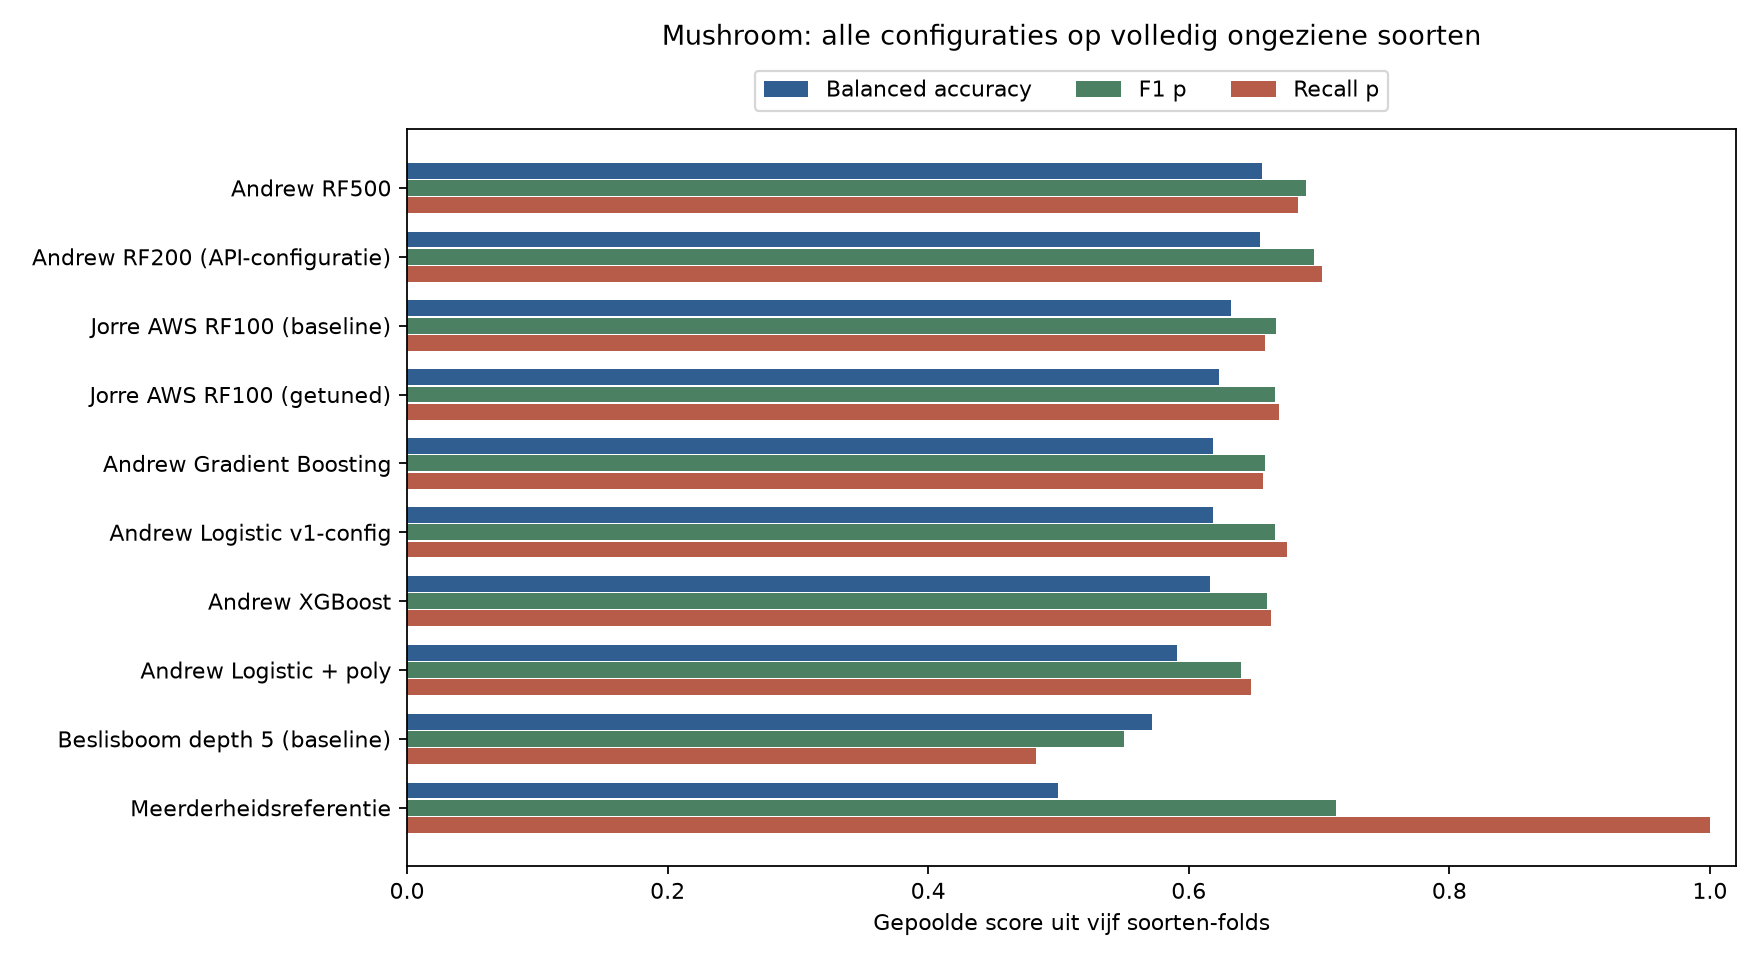

In [5]:
y = (predictions.true_class == 'p').astype(int)
functions = {'accuracy': accuracy_score, 'balanced_accuracy': balanced_accuracy_score,
             'precision_poisonous': precision_score, 'recall_poisonous': recall_score, 'f1_poisonous': f1_score}
for key, row in metrics.iterrows():
    labels = (predictions[key + '_prediction'] == 'p').astype(int)
    proba = predictions[key + '_probability_p']
    for name, function in functions.items():
        value = function(y, labels) if name in ['accuracy', 'balanced_accuracy'] else function(y, labels, zero_division=0)
        assert abs(value - row[name]) < 1e-12
    assert abs(roc_auc_score(y, proba) - row.roc_auc) < 1e-12
    assert abs(average_precision_score(y, proba) - row.average_precision) < 1e-12
    assert confusion_matrix(y, labels, labels=[0, 1]).ravel().tolist() == [int(row[c]) for c in ['tn', 'fp', 'fn', 'tp']]
    for fold in range(1, 6):
        take = split.validation_fold == fold
        saved = folds[(folds.model == key) & (folds.fold == fold)].iloc[0]
        for name, function in functions.items():
            value = function(y[take], labels[take]) if name in ['accuracy', 'balanced_accuracy'] else function(y[take], labels[take], zero_division=0)
            assert abs(value - saved[name]) < 1e-12
    for name in ['accuracy', 'balanced_accuracy', 'recall_poisonous', 'f1_poisonous']:
        assert abs(folds.loc[folds.model == key, name].mean() - row['cv_' + name + '_mean']) < 1e-12
display(metrics.loc[[*ranking.index, 'majority'], ['accuracy', 'balanced_accuracy', 'precision_poisonous', 'recall_poisonous', 'f1_poisonous', 'roc_auc', 'average_precision', 'fn', 'fp']])
display(folds.pivot(index='fold', columns='model', values='balanced_accuracy'))
display(Image(filename=str(OUT / 'metrics.png')))

## 5. Foutanalyse en grenzen

FN is `p` voorspeld als `e`; FP is `e` voorspeld als `p`. De aantallen staan afzonderlijk
omdat accuracy niet vertelt welke fout wordt gemaakt.

| Configuratie | TN e→e | FP e→p | FN p→e | TP p→p |
| --- | --- | --- | --- | --- |
| Andrew RF500 | 17099 | 10082 | 10674 | 23068 |
| Andrew RF200 (API-configuratie) | 16502 | 10679 | 10034 | 23708 |
| Jorre AWS RF100 (baseline) | 16487 | 10694 | 11526 | 22216 |
| Jorre AWS RF100 (getuned) | 15695 | 11486 | 11153 | 22589 |
| Andrew Gradient Boosting | 15791 | 11390 | 11576 | 22166 |
| Andrew Logistic v1-config | 15266 | 11915 | 10941 | 22801 |
| Andrew XGBoost | 15466 | 11715 | 11360 | 22382 |
| Andrew Logistic + poly | 14500 | 12681 | 11874 | 21868 |
| Beslisboom depth 5 (baseline) | 17963 | 9218 | 17446 | 16296 |
| Meerderheidsreferentie | 0 | 27181 | 0 | 33742 |

![Confusion matrices op dezelfde soorten-folds](comparison_species/confusion_matrices.png)

De gekozen configuratie mist 10,674 van 33,742 p-records
(31.63%), verdeeld over 54 soorten met minstens één FN.
Hier zijn drie FN-records met de laagste p-score, dus voorbeelden van relatief
overtuigde verkeerde voorspellingen. De score is een modelschatting, geen bewezen kans.

| Bronrij (0-based) | Soortgroep | Werkelijk → voorspeld | Score p | Ontbrekende kenmerken |
| --- | --- | --- | --- | --- |
| 23135 | 65 | p → e | 0.0099 | 5 |
| 23220 | 65 | p → e | 0.0109 | 5 |
| 23103 | 65 | p → e | 0.0110 | 5 |

De vijf soorten met de hoogste FN-fractie bij deze configuratie:

| Primaire soort | Groep | FN / records | FN-fractie |
| --- | --- | --- | --- |
| False Panther Cap | 2 | 353 / 353 | 100.00% |
| Ivory Clitocybe | 20 | 353 / 353 | 100.00% |
| Wood Woolly-foot | 21 | 353 / 353 | 100.00% |
| Stinking Russula | 65 | 353 / 353 | 100.00% |
| Birch Russula | 67 | 353 / 353 | 100.00% |

Voor deze soorten bestaan geen trainingsvoorbeelden binnen hun evaluatiefold.
De fouten wijzen op zwakke overdracht naar die soorten; ze bewijzen niet welk kenmerk
de fout veroorzaakt. Omdat de data gesimuleerd is en soortgroepen intern verwant zijn,
worden tienduizenden records niet voorgesteld als evenveel onafhankelijke veldwaarnemingen.
Er wordt geen naïeve rijgewijze significantietoets gebruikt om een winnaar te bewijzen.
Alle fouten met twintig bronfeatures en fold/soortgroep staan in
[selected_error_records.csv](comparison_species/selected_error_records.csv).
Foutaantallen per soort en per configuratie staan in
[species_errors.csv](comparison_species/species_errors.csv).


,tn,fp,fn,tp
model,,,,
decision_tree_5,17963,9218,17446,16296
aws_tuned,15695,11486,11153,22589
aws_baseline,16487,10694,11526,22216
random_forest_200,16502,10679,10034,23708
random_forest_500,17099,10082,10674,23068
gradient_boosting,15791,11390,11576,22166
xgboost,15466,11715,11360,22382
logistic_polynomial,14500,12681,11874,21868
logistic_artifact_config,15266,11915,10941,22801


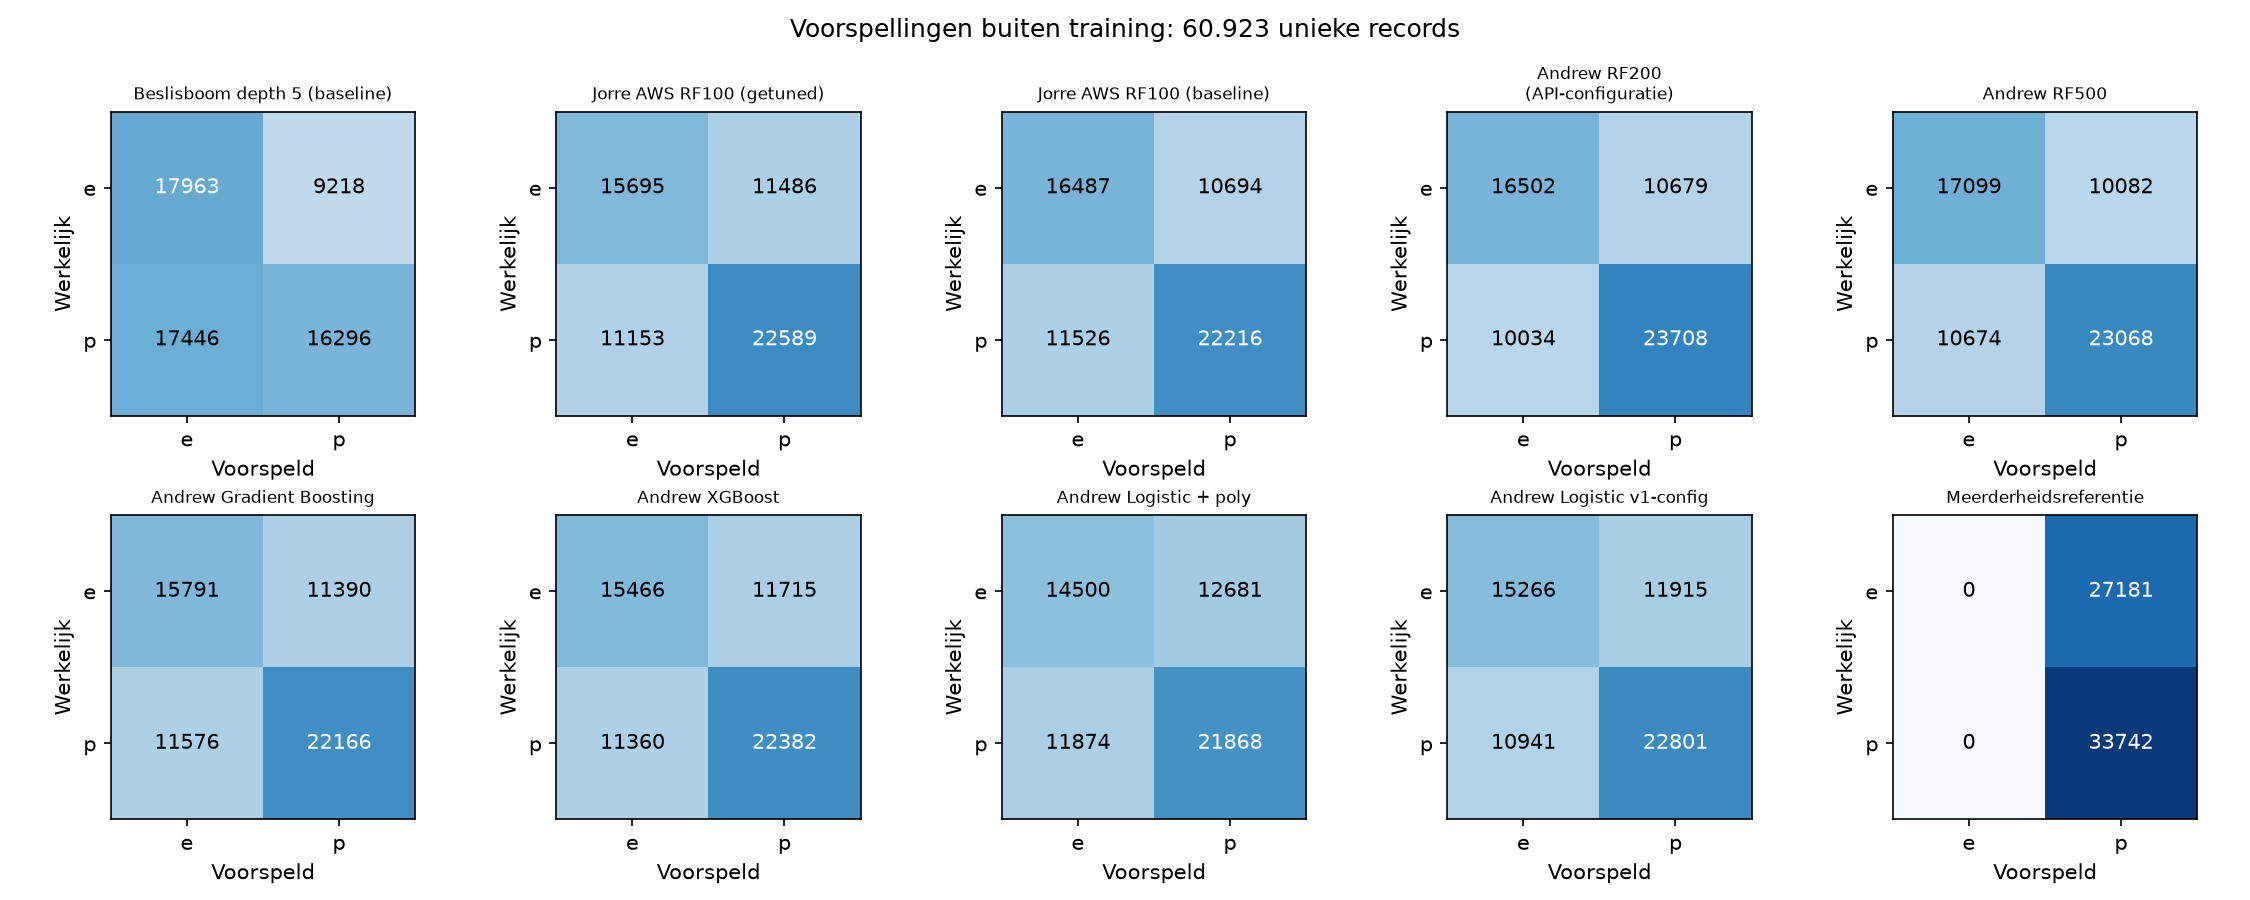

,unique_row,source_row,species_group,true_class,validation_fold,predicted_class,probability_p,missing_features,cap-diameter,cap-shape,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
8840,23133,23135,65,p,2,e,0.009927,5,7.52,x,...,NaN,NaN,w,NaN,NaN,f,f,NaN,d,u
8925,23218,23220,65,p,2,e,0.010948,5,7.65,x,...,NaN,NaN,w,NaN,NaN,f,f,NaN,d,a
8808,23101,23103,65,p,2,e,0.011020,5,8.40,x,...,NaN,NaN,w,NaN,NaN,f,f,NaN,d,a


,model,species_group,records,class,correct,fn,fp,name,fn_fraction
2,random_forest_500,2,353,p,0,353,0,False Panther Cap,1.0
20,random_forest_500,20,353,p,0,353,0,Ivory Clitocybe,1.0
21,random_forest_500,21,353,p,0,353,0,Wood Woolly-foot,1.0
65,random_forest_500,65,353,p,0,353,0,Stinking Russula,1.0
67,random_forest_500,67,353,p,0,353,0,Birch Russula,1.0


In [6]:
selected = summary['selected_model']
assert len(errors) == metrics.loc[selected, 'fn'] + metrics.loc[selected, 'fp']
wrong = predictions[predictions[selected + '_prediction'] != predictions.true_class]
assert set(errors.unique_row) == set(wrong.unique_row)
assert (errors.predicted_class != errors.true_class).all()
display(metrics[['tn', 'fp', 'fn', 'tp']].astype(int))
display(Image(filename=str(OUT / 'confusion_matrices.png')))
display(errors[errors.true_class == 'p'].sort_values('probability_p').head(3))
lookup = pd.read_csv(FOLDER / 'comparison_team/species_lookup.csv')
by_species = species_errors[species_errors.model == selected].merge(lookup[['species_group','name']], on='species_group')
assert by_species.fn.sum() == metrics.loc[selected,'fn']
assert by_species.fp.sum() == metrics.loc[selected,'fp']
by_species['fn_fraction'] = by_species.fn / by_species.records
display(by_species[by_species['class'] == 'p'].sort_values(['fn_fraction','fn'], ascending=False).head(5))

## 6. Training, eenvoud en praktische afweging

| Configuratie | Gem. fit per fold (s) | Gem. train accuracy | Gem. validatie accuracy |
| --- | --- | --- | --- |
| Andrew RF500 | 8.18 | Niet opnieuw gemeten | 0.6591 |
| Andrew RF200 (API-configuratie) | 11.95 | 1.0000 | 0.6599 |
| Jorre AWS RF100 (baseline) | 5.81 | 1.0000 | 0.6351 |
| Jorre AWS RF100 (getuned) | 4.99 | Niet opnieuw gemeten | 0.6281 |
| Andrew Gradient Boosting | 845.42 | 1.0000 | 0.6231 |
| Andrew Logistic v1-config | 0.83 | 0.8585 | 0.6245 |
| Andrew XGBoost | 2.01 | 0.9996 | 0.6215 |
| Andrew Logistic + poly | 1.32 | 0.8725 | 0.5970 |
| Beslisboom depth 5 (baseline) | 0.37 | 0.7690 | 0.5627 |
| Meerderheidsreferentie | 0.30 | 0.5539 | 0.5539 |

Tijden zijn lokale Windows-metingen, geen AWS-kosten of Render-latencybenchmark.
AWS gebruikt twee threads; RF500/XGBoost gebruiken beschikbare threads; RF200 behoudt
de bestaande instellingen. AWS getuned en RF500 hergebruiken de geverifieerde resultaten
van de eerdere identieke soorten-folds, inclusief toen gemeten fit-tijden. Hun trainmetrics
werden niet opgeslagen en worden niet achteraf ingevuld. Andere foldruns bewaren trainmetrics.
Een train-validatiekloof beschrijft gedrag, maar bewijst niet één oorzaak.
Er zijn 0 vastgelegde waarschuwingen tijdens de nieuwe evaluatie/refit;
de volledige berichten staan in het resultaat-JSON en worden in het notebook getoond.

Voor modelkeuze wegen de groepsvalidatiescores zwaarder dan snelheid. Een eenvoudiger
model kan voldoende zijn als de score vergelijkbaar is; het type algoritme, aantal bomen
of het gebruik van AWS bewijst op zichzelf geen betere generalisatie.


In [7]:
display(folds.groupby('model')[['fit_seconds','train_accuracy','accuracy','train_f1_poisonous','f1_poisonous']].mean())
display(pd.Series({k: sum(v.values()) for k,v in summary['warnings'].items()}, name='aantal waarschuwingen'))
display(summary['warnings'])

,fit_seconds,train_accuracy,accuracy,train_f1_poisonous,f1_poisonous
model,,,,,
aws_baseline,5.808168,1.000000,0.635096,1.000000,0.665651
aws_tuned,4.987308,NaN,0.628073,NaN,0.664885
decision_tree_5,0.368410,0.768997,0.562724,0.767662,0.534639
gradient_boosting,845.423998,1.000000,0.623082,1.000000,0.658555
logistic_artifact_config,0.825903,0.858499,0.624494,0.871212,0.666833
logistic_polynomial,1.323752,0.872463,0.597008,0.881509,0.640858
majority,0.301064,0.553853,0.553940,0.712875,0.712926
random_forest_200,11.951295,1.000000,0.659885,1.000000,0.694966
random_forest_500,8.182450,NaN,0.659116,NaN,0.688375


decision_tree_5             0
aws_tuned                   0
aws_baseline                0
random_forest_200           0
random_forest_500           0
gradient_boosting           0
xgboost                     0
logistic_polynomial         0
logistic_artifact_config    0
majority                    0
selected_full_refit         0
Name: aantal waarschuwingen, dtype: int64

{'decision_tree_5': {},
 'aws_tuned': {},
 'aws_baseline': {},
 'random_forest_200': {},
 'random_forest_500': {},
 'gradient_boosting': {},
 'xgboost': {},
 'logistic_polynomial': {},
 'logistic_artifact_config': {},
 'majority': {},
 'selected_full_refit': {}}

## 7. Eindkeuze, deployment en resterende opdrachtvereisten

**Kies voorlopig Andrew RF500 voor het vastgelegde doel 'ongeziene gesimuleerde soorten'.**
Dit is de hoogst scorende beschikbare getrainde configuratie onder het beschreven
balanced-accuracyprotocol. Rapporteer daarbij de recall, FN en spreiding; de uitkomsten
onderbouwen geen perfecte voorspellingen of prestaties op echte paddenstoelen.

Een volledige hertraining van deze configuratie op de 60.923 unieke records is opgeslagen
als [selected_pipeline.joblib](comparison_species/selected_pipeline.joblib), met twintig
inputs en volledige preprocessing. De outputlabels zijn `0=e` en `1=p`; een API moet
deze mapping expliciet toepassen. Die fit is een overdrachtsartifact: de trainingsscore
ervan geldt niet als extra testresultaat. De versie- en hashgegevens staan in het JSON.

De live Mushroom-API gebruikt nog de eerdere Andrew RF200 met twaalf inputs.
Een omschakeling vraagt een bewuste keuze, passende serving-versies, twintig frontend/API-
velden, de juiste labelmapping en een controle van API-voorspellingen tegen dezelfde pipeline. Deze vergelijking
wijzigt de backend niet. De Citi Bike-deployment van het team blijft een afzonderlijk onderdeel.

Voor de eindinlevering volgens de opdracht:

1. Laat het team deze vergelijking en de preprocessing reviewen en zelf kunnen uitleggen.
2. Voeg eventueel nog ontbrekende AutoML- en tuningruns toe onder hetzelfde groepsprotocol.
   Houd tuning volledig binnen trainingsgroepen; verander geen drempel op de eindtest.
3. Er is geen onaangeraakte eindtest meer voor dit ontwikkeltraject. Leg vóór nieuw
   onderzoek een onafhankelijke evaluatie vast, of motiveer deze groeps-CV als de
   beschikbare ontwikkelvalidatie. Noem de huidige scores geen finale onafhankelijke test.
4. Controleer ook de overige opdrachtbestanden: EDA, definitieve voorbereiding, model-
   notebooks per dataset, AWS-notebook, Citi Bike-vergelijking en werkende deploymentpipeline.

De modelvergelijking is hiermee uitgevoerd; dit rapport verklaart niet het hele project
automatisch af. De opdracht vraagt uiteindelijk een GitHub-link en een mondelinge verdediging.


In [8]:
artifact = OUT / summary['selected_full_refit_artifact']['path']
assert hashlib.sha256(artifact.read_bytes()).hexdigest() == summary['selected_full_refit_artifact']['sha256']
assert summary['selected_full_refit_artifact']['training_rows'] == 60923
assert not summary['protocol']['untouched_final_test']
print('Keuze is ontwikkelvalidatie; de full-data pipeline is geen nieuwe testscore.')
display(pd.Series(summary['selected_full_refit_artifact']))

Keuze is ontwikkelvalidatie; de full-data pipeline is geen nieuwe testscore.


path                                        selected_pipeline.joblib
bytes                                                        9694504
sha256             dba934c55ef07b2137006f9b05f02371a5b6f763ebeb5d...
training_rows                                                  60923
feature_columns    [cap-diameter, cap-shape, cap-surface, cap-col...
class_encoding                                      {'e': 0, 'p': 1}
purpose            Handoff only; training metrics are not validat...
dtype: object

## 8. Reproduceren en bewaarde bewijzen

De nieuwe fits gebruiken de gepinde omgeving uit `comparison-requirements.txt`:

```powershell
py -3.13 -m venv .venv-analysis
.\.venv-analysis\Scripts\python.exe -m pip install -r secondary_mushroom/comparison-requirements.txt
.\.venv-analysis\Scripts\python.exe secondary_mushroom/compare_species_models.py
.\.venv-analysis\Scripts\python.exe secondary_mushroom/build_species_comparison_report.py --execute
```

De scripts downloaden de oorspronkelijke UCI-data met code en controleren soortgroepen.
De twee eerder geverifieerde configuraties worden alleen bij dezelfde data, folds en
parameters hergebruikt. De overige resultaten worden per configuratie bewaard zodat
onderbroken runs kunnen worden hervat. Het notebook leest standaard de opgeslagen
voorspellingen, berekent de metrics opnieuw en controleert de selectie en soortscheiding.
Voor een nieuwe volledige run kunnen de per-configuratie resultaatcaches worden verwijderd.
Het originele AWS-artifact wordt uitsluitend in zijn afzonderlijke 1.7.2-auditomgeving geladen.

| Bewijs | Bestand |
| --- | --- |
| Eén uitgevoerd vergelijkingsnotebook | [09_compare_models.ipynb](09_compare_models.ipynb) |
| Trainings- en vergelijkingscode | [compare_species_models.py](compare_species_models.py) |
| Rapport/notebookgenerator | [build_species_comparison_report.py](build_species_comparison_report.py) |
| Vastgelegd protocol | [protocol.json](comparison_species/protocol.json) |
| Scores, parameters, omgeving, waarschuwingen en modelkeuze | [comparison_summary.json](comparison_species/comparison_summary.json) |
| Exacte metrictabel | [model_comparison.csv](comparison_species/model_comparison.csv) |
| Alle 50 fold-evaluaties | [cv_folds.csv](comparison_species/cv_folds.csv) |
| Bronrij, soortgroep en fold van iedere unieke rij | [split_manifest.csv](comparison_species/split_manifest.csv) |
| Alle labels en p-scores buiten training | [oof_predictions.csv](comparison_species/oof_predictions.csv) |
| Volledig hertrainde gekozen pipeline | [selected_pipeline.joblib](comparison_species/selected_pipeline.joblib) |

Versies: Python 3.13.7, scikit-learn 1.9.1,
pandas 3.0.2, NumPy 2.5.3 en joblib
1.6.0. Modelhash: `dba934c55ef07b2137006f9b05f02371a5b6f763ebeb5d7e333e898a8be42f61`.
Voor het laden van het artifact moet `secondary_mushroom` op het Python-importpad staan;
de pipeline verwijst waar nodig naar de bewaarde schoonmaakfunctie in `compare_andrew_models`.
Bewaar deze bestanden en gebruik dezelfde dependencies bij reproductie.
